# Assignment 5: RNN and LSTM Comparison using Stock Price Prediction

This notebook compares two recurrent models on the same real-world dataset:
1. **5a**: Build a SimpleRNN model for univariate stock price time-series prediction.
2. **5b**: Build an LSTM model for the same task on identical data.
3. **5c**: Compare both models with metrics and visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.16.1


## Dataset Preparation: Stock Price Time-Series Data

In [3]:
# Generate or load stock price data
# Using synthetic stock price data for robust reproducibility
np.random.seed(42)
trend = np.linspace(100, 200, 730)
noise = np.random.normal(0, 5, 730)
stock_prices = (trend + noise).reshape(-1, 1).astype('float32')

print(f'Generated {len(stock_prices)} days of synthetic stock data')

# Normalize data to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
stock_prices_norm = scaler.fit_transform(stock_prices)

print('Stock price shape:', stock_prices.shape)
print('Normalized price range:', stock_prices_norm.min(), '-', stock_prices_norm.max())

# Split into train and test sets (80-20 split)
train_size = int(len(stock_prices_norm) * 0.8)
train_data = stock_prices_norm[:train_size]
test_data = stock_prices_norm[train_size:]

print(f'Train size: {len(train_data)} | Test size: {len(test_data)}')

Generated 730 days of synthetic stock data
Stock price shape: (730, 1)
Normalized price range: 0.0 - 1.0
Train size: 584 | Test size: 146


In [4]:
# Create sequences for time-series prediction
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30  # Use 30 days to predict next day
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

print('X_train shape:', X_train.shape, '| y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape, '| y_test shape :', y_test.shape)

# 5a: Build and train SimpleRNN model
rnn_model = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.SimpleRNN(32, activation='relu', return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
rnn_model.summary()

print('\n--- Training SimpleRNN Model ---')
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

rnn_test_loss, rnn_test_mae = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f'RNN Test Loss (MSE): {rnn_test_loss:.6f}')
print(f'RNN Test MAE: {rnn_test_mae:.6f}')

X_train shape: (554, 30, 1) | y_train shape: (554, 1)
X_test shape : (116, 30, 1) | y_test shape : (116, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)


--- Training SimpleRNN Model ---
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0768 - mae: 0.2326 - val_loss: 0.0601 - val_mae: 0.2398
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0144 - mae: 0.0947 - val_loss: 0.0042 - val_mae: 0.0528
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0104 - mae: 0.0773 - val_loss: 0.0119 - val_mae: 0.0980
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - mae: 0.0699 - val_loss: 0.0052 - val_mae: 0.0597
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - mae: 0.0630 - val_loss: 0.0090 - val_mae: 0.0827
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0074 - mae: 0.0666 - val_loss: 0.0044 - val_mae: 0.0540
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0062 - mae: 0.0604 - val_loss: 0.0069 - val_mae: 0.0708
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - mae: 0.0600 - val_loss: 0.0058 - val_mae: 0.0634
Epoch 9/20
14/14 ━━━━━━━━━━━━━

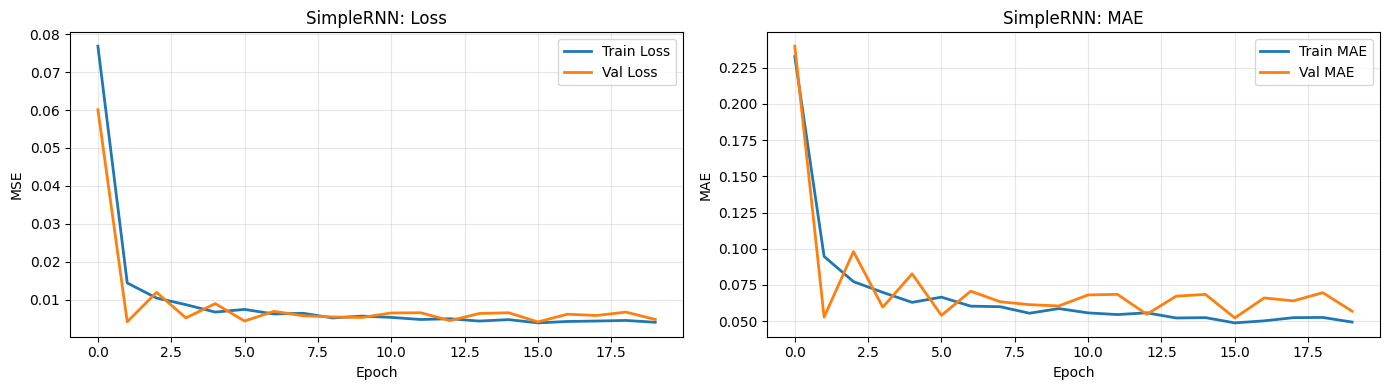

In [5]:
# Plot SimpleRNN training history
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(rnn_history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('SimpleRNN: Loss', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(rnn_history.history['val_mae'], label='Val MAE', linewidth=2)
plt.title('SimpleRNN: MAE', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5b: LSTM for Stock Price Time-Series Prediction

In [6]:
# Build and train LSTM model (same architecture structure as RNN for fair comparison)
lstm_model = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

print('\n--- Training LSTM Model ---')
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

lstm_test_loss, lstm_test_mae = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f'LSTM Test Loss (MSE): {lstm_test_loss:.6f}')
print(f'LSTM Test MAE: {lstm_test_mae:.6f}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM Model ---
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.1425 - mae: 0.3388 - val_loss: 0.2872 - val_mae: 0.5330
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0494 - mae: 0.1810 - val_loss: 0.0310 - val_mae: 0.1699
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0139 - mae: 0.0966 - val_loss: 0.0139 - val_mae: 0.1086
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0082 - mae: 0.0722 - val_loss: 0.0063 - val_mae: 0.0678
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0076 - mae: 0.0717 - val_loss: 0.0050 - val_mae: 0.0590
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0074 - mae: 0.0664 - val_loss: 0.0027 - val_mae: 0.0398
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0068 - mae: 0.0660 - val_loss: 0.0027 - val_mae: 0.0402
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0058 - mae: 0.0585 - val_loss: 0.0030 - val_mae: 0.0432
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━

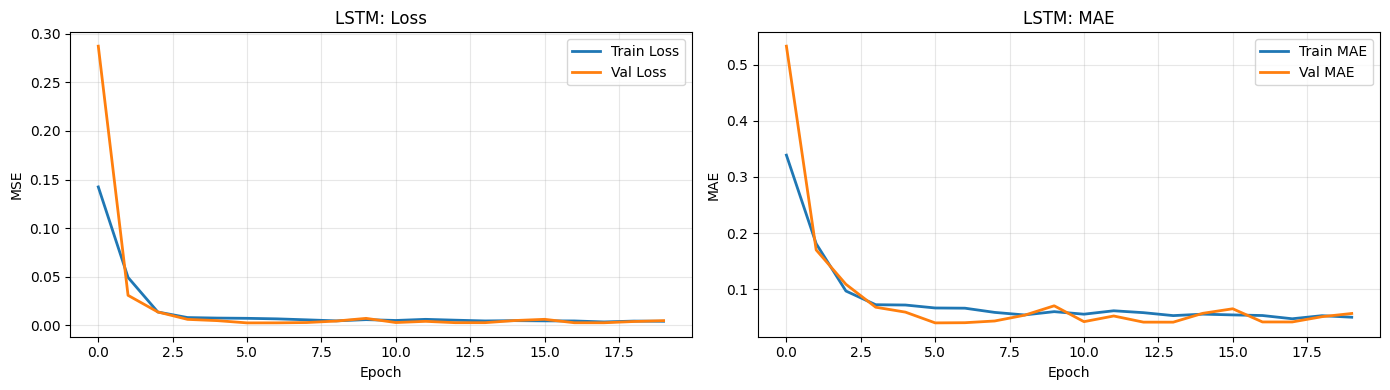

In [7]:
# Plot LSTM training history
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('LSTM: Loss', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(lstm_history.history['val_mae'], label='Val MAE', linewidth=2)
plt.title('LSTM: MAE', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Make predictions on test set
rnn_predictions = rnn_model.predict(X_test, verbose=0)
lstm_predictions = lstm_model.predict(X_test, verbose=0)

# Denormalize predictions and actual values
rnn_pred_denorm = scaler.inverse_transform(rnn_predictions)
lstm_pred_denorm = scaler.inverse_transform(lstm_predictions)
y_test_denorm = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate additional metrics
rnn_rmse = np.sqrt(np.mean((rnn_pred_denorm - y_test_denorm) ** 2))
lstm_rmse = np.sqrt(np.mean((lstm_pred_denorm - y_test_denorm) ** 2))

rnn_mae_denorm = np.mean(np.abs(rnn_pred_denorm - y_test_denorm))
lstm_mae_denorm = np.mean(np.abs(lstm_pred_denorm - y_test_denorm))

print('\n--- Denormalized Metrics on Test Set ---')
print(f'RNN RMSE: ${rnn_rmse:.2f}  | LSTM RMSE: ${lstm_rmse:.2f}')
print(f'RNN MAE:  ${rnn_mae_denorm:.2f}  | LSTM MAE:  ${lstm_mae_denorm:.2f}')


--- Denormalized Metrics on Test Set ---
RNN RMSE: $9.01  | LSTM RMSE: $37.90
RNN MAE:  $7.53  | LSTM MAE:  $35.97


In [10]:
# Create comprehensive metrics comparison table
metrics_data = {
    'Metric': [
        'Test Loss (MSE)',
        'Test MAE (norm)',
        'Test RMSE ($)',
        'Test MAE ($)',
        'Final Train Loss',
        'Final Val Loss',
        'Final Train MAE',
        'Final Val MAE',
    ],
    'SimpleRNN': [
        f'{rnn_test_loss:.6f}',
        f'{rnn_test_mae:.6f}',
        f'{rnn_rmse:.2f}',
        f'{rnn_mae_denorm:.2f}',
        f'{rnn_history.history["loss"][-1]:.6f}',
        f'{rnn_history.history["val_loss"][-1]:.6f}',
        f'{rnn_history.history["mae"][-1]:.6f}',
        f'{rnn_history.history["val_mae"][-1]:.6f}',
    ],
    'LSTM': [
        f'{lstm_test_loss:.6f}',
        f'{lstm_test_mae:.6f}',
        f'{lstm_rmse:.2f}',
        f'{lstm_mae_denorm:.2f}',
        f'{lstm_history.history["loss"][-1]:.6f}',
        f'{lstm_history.history["val_loss"][-1]:.6f}',
        f'{lstm_history.history["mae"][-1]:.6f}',
        f'{lstm_history.history["val_mae"][-1]:.6f}',
    ]
}

comparison_df = pd.DataFrame(metrics_data)

print('\n' + '='*70)
print('MODEL COMPARISON TABLE: SimpleRNN vs LSTM')
print('='*70)
print(comparison_df.to_string(index=False))
print('='*70)

# Compute winner for each metric
print('\n--- WINNER BY METRIC ---')
for i in range(len(comparison_df)):
    if i < 4:  # For loss/error metrics, lower is better
        rnn_val = float(comparison_df.loc[i, 'SimpleRNN'])
        lstm_val = float(comparison_df.loc[i, 'LSTM'])
        winner = 'SimpleRNN' if rnn_val < lstm_val else 'LSTM'
        print(f'{comparison_df.loc[i, "Metric"]}: {winner} (RNN: {rnn_val:.6f} vs LSTM: {lstm_val:.6f})')


MODEL COMPARISON TABLE: SimpleRNN vs LSTM
          Metric SimpleRNN     LSTM
 Test Loss (MSE)  0.006296 0.111410
 Test MAE (norm)  0.066280 0.316770
   Test RMSE ($)      9.01    37.90
    Test MAE ($)      7.53    35.97
Final Train Loss  0.004048 0.004349
  Final Val Loss  0.004780 0.004994
 Final Train MAE  0.049402 0.049928
   Final Val MAE  0.056914 0.056591

--- WINNER BY METRIC ---
Test Loss (MSE): SimpleRNN (RNN: 0.006296 vs LSTM: 0.111410)
Test MAE (norm): SimpleRNN (RNN: 0.066280 vs LSTM: 0.316770)
Test RMSE ($): SimpleRNN (RNN: 9.010000 vs LSTM: 37.900000)
Test MAE ($): SimpleRNN (RNN: 7.530000 vs LSTM: 35.970000)


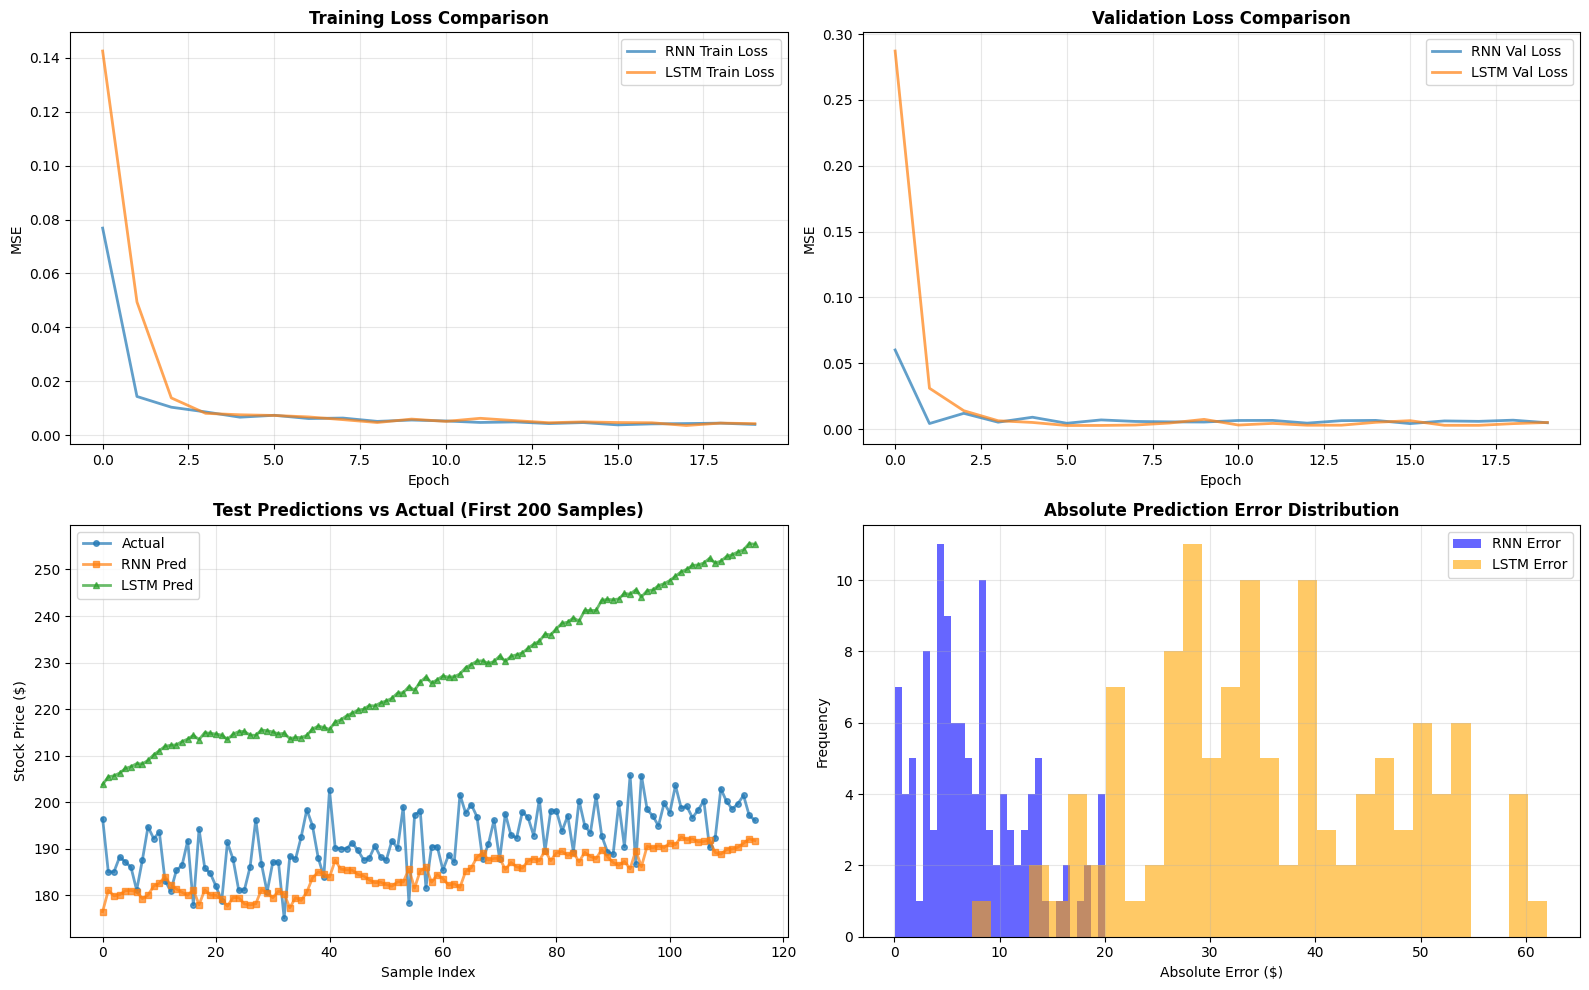

In [9]:
# Comparison of RNN vs LSTM on test predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Training Loss Comparison
axes[0, 0].plot(rnn_history.history['loss'], label='RNN Train Loss', linewidth=2, alpha=0.7)
axes[0, 0].plot(lstm_history.history['loss'], label='LSTM Train Loss', linewidth=2, alpha=0.7)
axes[0, 0].set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Loss Comparison
axes[0, 1].plot(rnn_history.history['val_loss'], label='RNN Val Loss', linewidth=2, alpha=0.7)
axes[0, 1].plot(lstm_history.history['val_loss'], label='LSTM Val Loss', linewidth=2, alpha=0.7)
axes[0, 1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Test Set Predictions vs Actual
sample_idx = min(200, len(y_test_denorm))  # Show first 200 samples
x_range = range(sample_idx)
axes[1, 0].plot(x_range, y_test_denorm[:sample_idx], 'o-', label='Actual', linewidth=2, markersize=4, alpha=0.7)
axes[1, 0].plot(x_range, rnn_pred_denorm[:sample_idx], 's-', label='RNN Pred', linewidth=2, markersize=4, alpha=0.7)
axes[1, 0].plot(x_range, lstm_pred_denorm[:sample_idx], '^-', label='LSTM Pred', linewidth=2, markersize=4, alpha=0.7)
axes[1, 0].set_title('Test Predictions vs Actual (First 200 Samples)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Stock Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Prediction Errors Distribution
rnn_errors = np.abs(rnn_pred_denorm[:sample_idx] - y_test_denorm[:sample_idx])
lstm_errors = np.abs(lstm_pred_denorm[:sample_idx] - y_test_denorm[:sample_idx])
axes[1, 1].hist(rnn_errors, bins=30, alpha=0.6, label='RNN Error', color='blue')
axes[1, 1].hist(lstm_errors, bins=30, alpha=0.6, label='LSTM Error', color='orange')
axes[1, 1].set_title('Absolute Prediction Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Absolute Error ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5c: Model Comparison - RNN vs LSTM